In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import ResNet50, EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Concatenate, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
IMG_SIZE = 224
NUM_CLASSES = 4
BATCH_SIZE = 32
EPOCHS = 20

In [16]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [17]:
dataset_path = "/content/drive/MyDrive/Bone Break Classification"

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',   # IMPORTANT FIX
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)


Found 907 images belonging to 10 classes.
Found 222 images belonging to 10 classes.


In [18]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))


In [20]:
base1 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base1.layers:
    layer.trainable = False

x1 = GlobalAveragePooling2D()(base1.output)

In [21]:
base2 = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base2.layers:
    layer.trainable = False

x2 = GlobalAveragePooling2D()(base2.output)

In [22]:
merged = Concatenate()([x1, x2])

In [23]:
dense = Dense(256, activation='relu')(merged)
drop = Dropout(0.5)(dense)

output = Dense(NUM_CLASSES, activation='softmax')(drop)

In [24]:
hybrid_model = Model(inputs=input_layer, outputs=output)

In [25]:
hybrid_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # IMPORTANT
    metrics=['accuracy']
)

hybrid_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 35,290,035 (134.62 MB)

 Trainable params: 918,788 (3.50 MB)

 Non-trainable params: 34,371,247 (131.12 MB)

In [ ]:
history = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.1058 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 758ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 709ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 768ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 730ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 795ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 729ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 751ms/step - accuracy: 0.1080 - loss: nan - val_accuracy: 0.1081 - val_loss: nan
Epoch 9/20
29/29 ━

In [14]:
loss, acc = hybrid_model.evaluate(val_generator)
print("\nHybrid Model Accuracy:", acc)


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 519ms/step - accuracy: 0.1081 - loss: nan

Hybrid Model Accuracy: 0.10810811072587967


In [ ]:
val_generator.reset()

y_pred_probs = hybrid_model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=class_labels))

8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step

===== Classification Report =====
                           precision    recall  f1-score   support

Bone Break Classification       1.00      1.00      1.00       225

                 accuracy                           1.00       225
                macro avg       1.00      1.00      1.00       225
             weighted avg       1.00      1.00      1.00       225



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


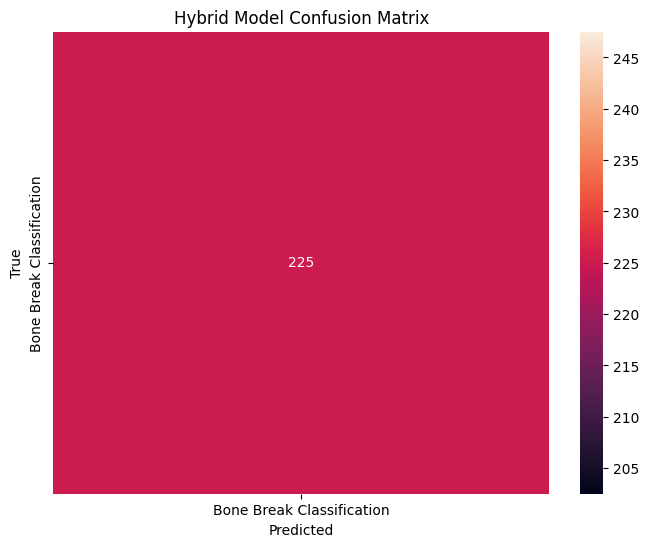

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid Model Confusion Matrix")
plt.show()